# Практика 11. Числові характеристики випадкової величини; закон великих чисел і ЦГТ симуляцією

**Варіант 7 — Івано-Франківськ**

Параметр експоненційного розподілу:
λ = 0.28 подій/хв.

Теоретичне середнє:
E[X] = 1 / λ = 3.5714 хв.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
rng = np.random.default_rng(7)

lam = 0.28
true_mean = 1 / lam

print("Місто: Івано-Франківськ")
print("Lambda:", lam)
print("Теоретичне середнє:", true_mean)

Місто: Івано-Франківськ
Lambda: 0.28
Теоретичне середнє: 3.571428571428571


## Завдання 1. Перевірка закону великих чисел

Для вибірок різного розміру порівнюємо вибіркове середнє з теоретичним значенням E[X] = 1/λ.

In [11]:
sample_sizes = [5, 50, 500, 20000]

for n in sample_sizes:
    sample = rng.exponential(
        scale=1 / lam,
        size=n
    )
    
    sample_mean = sample.mean()
    difference = abs(sample_mean - true_mean)
    
    print(f"n = {n}")
    print(f"Середнє = {sample_mean:.4f}")
    print(f"Абсолютна різниця = {difference:.4f}")
    print()

n = 5
Середнє = 2.4307
Абсолютна різниця = 1.1408

n = 50
Середнє = 3.4892
Абсолютна різниця = 0.0822

n = 500
Середнє = 3.6793
Абсолютна різниця = 0.1079

n = 20000
Середнє = 3.5913
Абсолютна різниця = 0.0199



### Висновок до Завдання 1

Зі збільшенням розміру вибірки вибіркове середнє в середньому наближається до теоретичного значення E[X] = 1/λ = 3.5714 хв. Абсолютна різниця між вибірковим і теоретичним середнім загалом зменшується. Це демонструє закон великих чисел. 

## Завдання 2. Вибірковий розподіл середнього для двох n

Досліджуємо розподіл вибіркових середніх для n = 10 та n = 300, використовуючи 10 000 повторних вибірок.

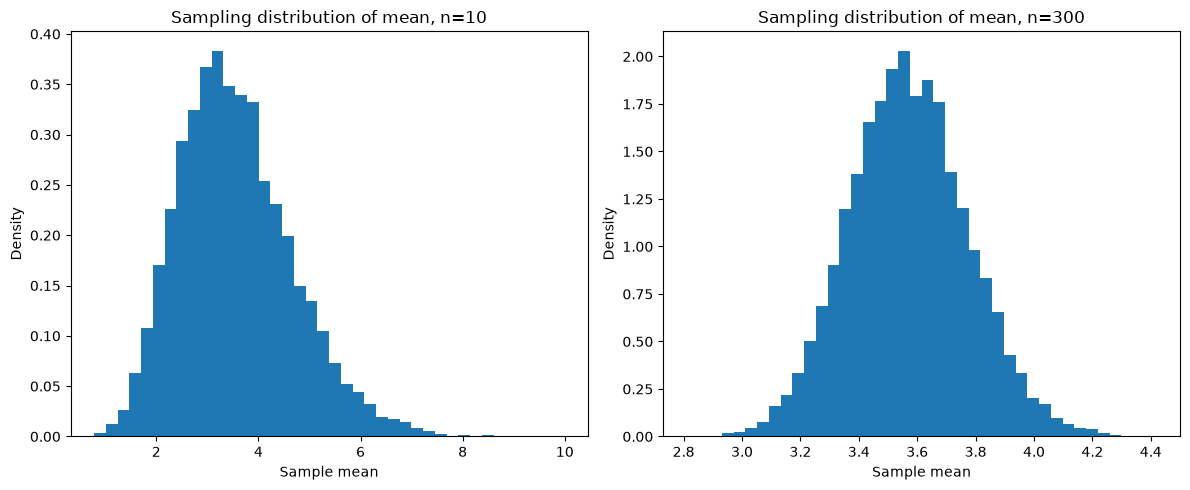

In [12]:
n_repeats = 10000

means_n10 = rng.exponential(
    scale=1 / lam,
    size=(n_repeats, 10)
).mean(axis=1)

means_n300 = rng.exponential(
    scale=1 / lam,
    size=(n_repeats, 300)
).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(means_n10, bins=40, density=True)
axes[0].set_title("Sampling distribution of mean, n=10")
axes[0].set_xlabel("Sample mean")
axes[0].set_ylabel("Density")

axes[1].hist(means_n300, bins=40, density=True)
axes[1].set_title("Sampling distribution of mean, n=300")
axes[1].set_xlabel("Sample mean")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

### Висновок до Завдання 2

Для n = 10 розподіл вибіркових середніх ще помітно скошений вправо, оскільки вихідний експоненційний розподіл також є скошеним. Для n = 300 розподіл середніх стає значно ближчим до дзвоноподібної нормальної форми. Це демонструє центральну граничну теорему: зі збільшенням n розподіл вибіркового середнього наближається до нормального.

## Завдання 3. Стандартна похибка: теорія проти симуляції

Порівнюємо теоретичну стандартну похибку SE = (1/λ) / √n з виміряним стандартним відхиленням вибіркових середніх.

In [13]:
sample_sizes_se = [10, 30, 100, 300]

results = []

for n in sample_sizes_se:
    sample_means = rng.exponential(
        scale=1 / lam,
        size=(n_repeats, n)
    ).mean(axis=1)
    
    theoretical_se = true_mean / np.sqrt(n)
    measured_std = sample_means.std()
    
    results.append(
        (n, theoretical_se, measured_std)
    )

print("n    Теоретична SE    Виміряна std")

for n, theoretical_se, measured_std in results:
    print(
        f"{n:<4} {theoretical_se:<17.4f} {measured_std:.4f}"
    )

n    Теоретична SE    Виміряна std
10   1.1294            1.1208
30   0.6521            0.6558
100  0.3571            0.3567
300  0.2062            0.2047


In [14]:
import pandas as pd

se_table = pd.DataFrame(
    results,
    columns=["n", "Theoretical SE", "Measured std"]
)

se_table

,n,Theoretical SE,Measured std
0,10,1.129385,1.120754
1,30,0.652051,0.655832
2,100,0.357143,0.356659
3,300,0.206197,0.204741


### Висновок до Завдання 3

Теоретична стандартна похибка та виміряне стандартне відхилення вибіркових середніх мають близькі значення. Невеликі відмінності пояснюються випадковістю симуляції. Зі збільшенням n стандартна похибка зменшується відповідно до формули SE = σ / √n.

## Завдання 4. Закон убуваючої віддачі

Порівнюємо стандартну похибку для n = 25 та n = 100.

In [15]:
n1 = 25
n2 = 100

se_25 = true_mean / np.sqrt(n1)
se_100 = true_mean / np.sqrt(n2)

print(f"SE для n=25: {se_25:.4f}")
print(f"SE для n=100: {se_100:.4f}")
print(f"Співвідношення SE(25) / SE(100): {se_25 / se_100:.2f}")

SE для n=25: 0.7143
SE для n=100: 0.3571
Співвідношення SE(25) / SE(100): 2.00


### Висновок до Завдання 4

При збільшенні розміру вибірки з 25 до 100, тобто у 4 рази, стандартна похибка зменшується у 2 рази. Це пояснюється формулою SE = σ / √n. Оскільки n знаходиться під квадратним коренем, збільшення вибірки у 4 рази дає лише дворазове зменшення стандартної похибки. Щоб зменшити похибку вдвічі, потрібно приблизно у 4 рази більше спостережень.

## Завдання 5. Вплив n_repeats на якість симуляції

Порівнюємо вибірковий розподіл середнього для n = 10 при 10 000 та 50 повторних вибірках.

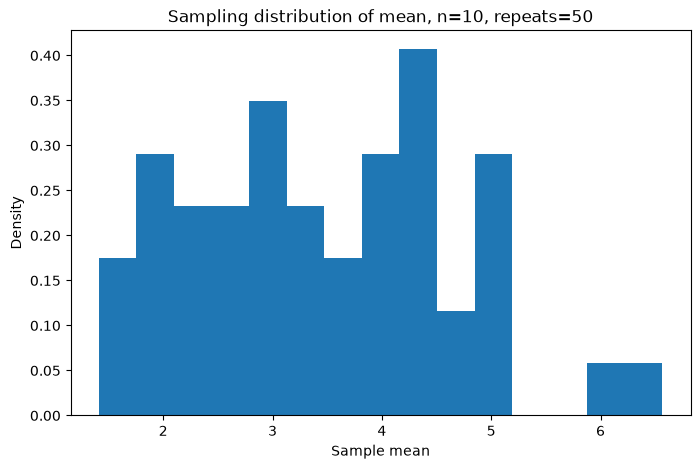

In [16]:
means_n10_50 = rng.exponential(
    scale=1 / lam,
    size=(50, 10)
).mean(axis=1)

plt.figure(figsize=(8, 5))

plt.hist(
    means_n10_50,
    bins=15,
    density=True
)

plt.xlabel("Sample mean")
plt.ylabel("Density")
plt.title("Sampling distribution of mean, n=10, repeats=50")

plt.show()

### Висновок до Завдання 5

При n_repeats = 50 гістограма є значно менш гладкою та менш стабільною, ніж гістограма з 10 000 повторень. Причина полягає в тому, що n_repeats визначає кількість значень вибіркового середнього, з яких будується гістограма. Чим більше повторень, тим краще видно форму розподілу. При цьому n визначає розмір кожної окремої вибірки та впливає на форму самого вибіркового розподілу відповідно до центральної граничної теореми.

# Контрольні питання

### 1. Чим відрізняється закон великих чисел від центральної граничної теореми?

Закон великих чисел відповідає на питання «куди прямує вибіркове середнє x̄?». Зі збільшенням розміру вибірки x̄ наближається до теоретичного математичного сподівання E[X].

Центральна гранична теорема відповідає на питання «яка форма та розкид у x̄?». За достатньо великого n розподіл вибіркового середнього наближається до нормального, а його стандартне відхилення визначається стандартною похибкою σ/√n.

### 2. Чому вихідний розподіл у практиці є сильно скошеним?

Експоненційний розподіл часу очікування є сильно скошеним вправо. Такий вибір потрібен для демонстрації центральної граничної теореми. Він показує, що навіть якщо вихідні дані не мають нормальної форми, розподіл вибіркового середнього при збільшенні n стає близьким до нормального. Якби вихідні дані вже були нормальними, цей ефект був би значно менш наочним.

### 3. Чому стандартна похибка зменшується пропорційно √n, а не n?

Стандартна похибка обчислюється за формулою SE = σ/√n. Тому для зменшення стандартної похибки у 2 рази потрібно збільшити розмір вибірки у 4 рази. Наприклад, перехід від n = 25 до n = 100 збільшує вибірку у 4 рази та зменшує SE у 2 рази. Це демонструє закон убуваючої віддачі: для подальшого зменшення похибки потрібно збирати дедалі більше спостережень.